In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("../data/raw/RawData.csv", sep=";")
df.head()

# Dimensiones
print(df.shape)

# Primeras filas
df.head()

# Tipos de datos y valores no nulos
df.info()


(424, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424 entries, 0 to 423
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       424 non-null    object 
 1   Edad             417 non-null    float64
 2   Sexo             417 non-null    float64
 3   Fumador          417 non-null    float64
 4   Dislipemia       417 non-null    float64
 5   Diabetes         417 non-null    float64
 6   HTA              417 non-null    float64
 7   IAM              417 non-null    float64
 8   ERC              393 non-null    float64
 9   EPOC             393 non-null    float64
 10  ACV              417 non-null    float64
 11  FA               393 non-null    float64
 12  CANCER           393 non-null    float64
 13  ICC              393 non-null    float64
 14  EAP              393 non-null    float64
 15  Diam AAA pre IQ  105 non-null    float64
 16  TTO              422 non-null    float64
 17  FORMA 

In [3]:
# Vamos a ver cuántas filas reciben el tratamiento 0, cuántas el 1 y cuántas el 2.
df['TTO'] = pd.to_numeric(df['TTO'], errors='coerce')

conteo = df['TTO'].value_counts(dropna=False).sort_index()

print("Conteo de filas por Tipo de Tratamiento (0, 1, 2):")
print(conteo)

# Lo vemos más o menos uniforme, con 40 muestras menos en el tipo de tratamiento 1
# Sin embargo vemos que esta tratando cada tipo como floats, y eso no lo queremos

Conteo de filas por Tipo de Tratamiento (0, 1, 2):
TTO
0.0    154
1.0    112
2.0    156
NaN      2
Name: count, dtype: int64


In [12]:
# Vamos a ver cada columna y el tipo de variable que tiene
# print(df.info())

# Datos faltantes o nulos

# Vamos a ver las columnas con mas de un 40% de datos nulos
columnas_faltanes = df.isnull().mean()
columnas_50 = columnas_faltanes[columnas_faltanes > 0.4]
# print(columnas_50)

# Vamos a ver las filas con más de un 40% de datos nulos
umbral_nulos = 0.4
porcentaje_nulos_por_fila = df.isnull().sum(axis=1) / len(df.columns)
df_filtrado = data2[porcentaje_nulos_por_fila < umbral_nulos]
print(df_filtrado)

'''
# Vamos a sacar Diam AAA pre IQ porque faltan el 75% de los datos
columnas_a_eliminar = columnas_50.index.tolist()
df.drop(labels=columnas_a_eliminar, axis=1, inplace=True)

# Todo está a float. Cambiaremos cada una a su tipo correspondiente
df["Edad"] = df["Edad"].astype('Int64')
df["Sexo"] = df["Sexo"].astype(bool)
df["Fumador"] = df["Fumador"].astype('Int64').astype("category")
df["Dislipemia"] = df["Dislipemia"].astype(bool)
df["Diabetes"] = df["Diabetes"].astype(bool)
df["HTA"] = df["HTA"].astype(bool)
df["IAM"] = df["IAM"].astype(bool)
df["ERC"] = df["ERC"].astype(bool)
df["EPOC"] = df["EPOC"].astype(bool)
df["ACV"] = df["ACV"].astype(bool)
df["FA"] = df["FA"].astype(bool)
df["CANCER"] = df["CANCER"].astype(bool)
df["ICC"] = df["ICC"].astype(bool)
df["EAP"] = df["EAP"].astype(bool)
df["TTO"] = df["TTO"].astype('Int64').astype("category")
df["FORMA INTERV"] = df["FORMA INTERV"].astype(bool)

print(df.info())
print(df.head())
'''


    Unnamed: 0  Edad  Sexo  Fumador  Dislipemia  Diabetes  HTA  IAM  ERC  \
0        LaFe1  72.0   0.0      1.0         1.0       0.0  0.0  0.0  0.0   
1       LaFe2   77.0   0.0      0.0         0.0       0.0  0.0  0.0  0.0   
2        LaFe3  66.0   0.0      0.0         1.0       0.0  0.0  0.0  0.0   
3        LaFe4  61.0   0.0      0.0         1.0       0.0  1.0  0.0  0.0   
4        LaFe5  54.0   0.0      0.0         1.0       0.0  0.0  0.0  0.0   
..         ...   ...   ...      ...         ...       ...  ...  ...  ...   
419    HUVH102  63.0   0.0      1.0         1.0       0.0  1.0  0.0  0.0   
420    HUVH103  60.0   0.0      1.0         0.0       0.0  1.0  0.0  0.0   
421    HUVH104  78.0   0.0      1.0         0.0       0.0  0.0  0.0  0.0   
422    HUVH105  64.0   0.0      1.0         0.0       0.0  1.0  0.0  0.0   
423    HUVH106  39.0   1.0      1.0         0.0       0.0  0.0  0.0  0.0   

     EPOC  ACV   FA  CANCER  ICC  EAP  Diam AAA pre IQ  TTO  FORMA INTERV  
0     1.0  

'\n# Vamos a sacar Diam AAA pre IQ porque faltan el 75% de los datos\ncolumnas_a_eliminar = columnas_50.index.tolist()\ndf.drop(labels=columnas_a_eliminar, axis=1, inplace=True)\n\n# Todo está a float. Cambiaremos cada una a su tipo correspondiente\ndf["Edad"] = df["Edad"].astype(\'Int64\')\ndf["Sexo"] = df["Sexo"].astype(bool)\ndf["Fumador"] = df["Fumador"].astype(\'Int64\').astype("category")\ndf["Dislipemia"] = df["Dislipemia"].astype(bool)\ndf["Diabetes"] = df["Diabetes"].astype(bool)\ndf["HTA"] = df["HTA"].astype(bool)\ndf["IAM"] = df["IAM"].astype(bool)\ndf["ERC"] = df["ERC"].astype(bool)\ndf["EPOC"] = df["EPOC"].astype(bool)\ndf["ACV"] = df["ACV"].astype(bool)\ndf["FA"] = df["FA"].astype(bool)\ndf["CANCER"] = df["CANCER"].astype(bool)\ndf["ICC"] = df["ICC"].astype(bool)\ndf["EAP"] = df["EAP"].astype(bool)\ndf["TTO"] = df["TTO"].astype(\'Int64\').astype("category")\ndf["FORMA INTERV"] = df["FORMA INTERV"].astype(bool)\n\nprint(df.info())\nprint(df.head())\n'

In [5]:
# Antes de hacer una matriz de correlación, sacaremos la primer columna que tiene el nombre del hospital y el número de paciente, que no es necesario
df.drop(columns=[df.columns[0]], inplace=True)
print(df.head())

   Edad   Sexo Fumador  Dislipemia  Diabetes    HTA    IAM    ERC   EPOC  \
0    72  False       1        True     False  False  False  False   True   
1    77  False       0       False     False  False  False  False   True   
2    66  False       0        True     False  False  False  False   True   
3    61  False       0        True     False   True  False  False  False   
4    54  False       0        True     False  False  False  False  False   

     ACV     FA  CANCER    ICC    EAP TTO  FORMA INTERV  
0  False  False    True  False  False   0          True  
1  False  False   False  False  False   2         False  
2  False  False   False  False  False   2         False  
3  False  False    True  False  False   2          True  
4  False  False   False  False   True   1         False  


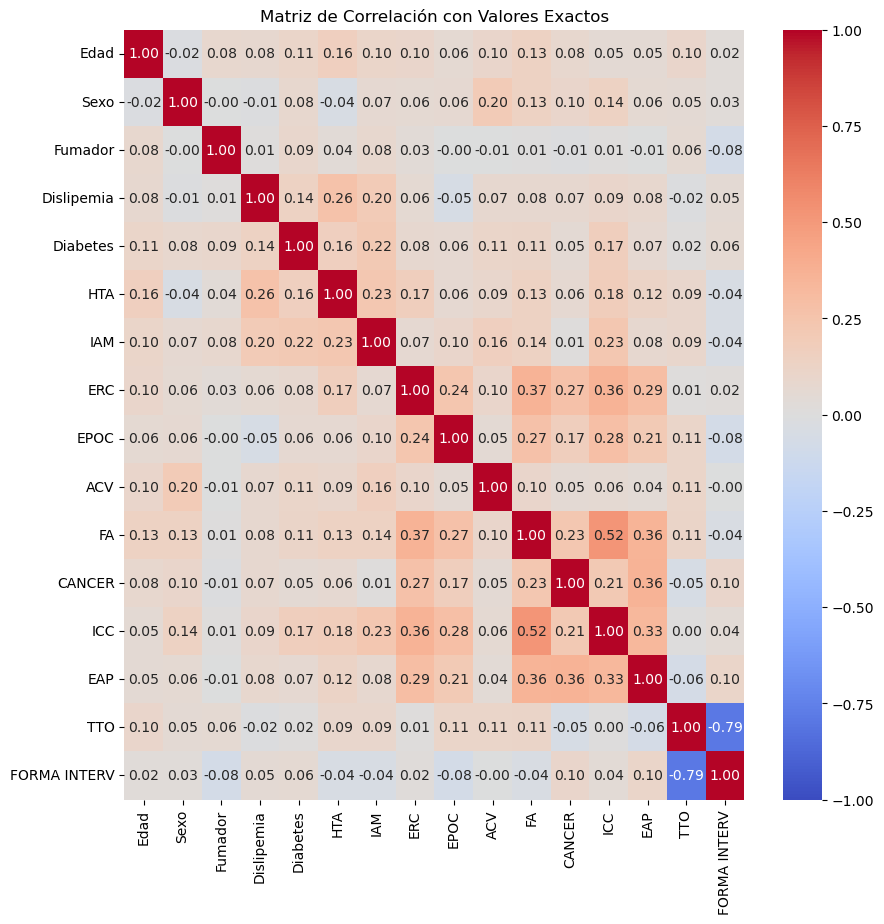

In [6]:
# Vamos a hacer una matriz de correlación para ver variables que se comporten de manera muy similar.
matriz_de_correlacion = df.corr()
plt.figure(figsize=(10, 10))
sns.heatmap(matriz_de_correlacion, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            vmin=-1, 
            vmax=1)

plt.title("Matriz de Correlación con Valores Exactos")
plt.show()